In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import os
import warnings
warnings.filterwarnings("ignore")

In [43]:
# %load load_data.py
from kaggle.api.kaggle_api_extended import KaggleApi
api = KaggleApi()
api.authenticate()

api.dataset_download_files('beatafaron/telco-customer-churn-realistic-customer-feedback' , unzip = True)


Dataset URL: https://www.kaggle.com/datasets/beatafaron/telco-customer-churn-realistic-customer-feedback


In [44]:
df = pd.read_csv("telco_churn_with_all_feedback.csv")

In [45]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,PromptInput,CustomerFeedback
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,Write a realistic customer feedback based on t...,I have been using the DSL internet service fro...
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.5,No,Write a realistic customer feedback based on t...,I have been a customer with this company for o...
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,Write a realistic customer feedback based on t...,I recently signed up for DSL internet service ...
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,Write a realistic customer feedback based on t...,I have been a loyal customer with this company...
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,Write a realistic customer feedback based on t...,I recently switched to this fiber optic intern...


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [51]:
#TotalCharges has the type object so lets inspect it further
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [52]:
#Filling the NaN values with median
df['TotalCharges'].fillna(value = df['TotalCharges'].median(),inplace = True)

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [54]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928
std,0.368612,24.559481,30.090047,2265.270398
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,402.225000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [61]:
# Check unique values for a specific column
print(df['Contract'].unique())
print(df['PaymentMethod'].unique())
print(df['InternetService'].unique())
print(df['MultipleLines'].unique())

['Month-to-month' 'One year' 'Two year']
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
['DSL' 'Fiber optic' 'No']
['No phone service' 'No' 'Yes']


In [14]:
#Checking any duplicated rows
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
7038    False
7039    False
7040    False
7041    False
7042    False
Length: 7043, dtype: bool

In [15]:
#Check for null values
df.isnull().count()

customerID          7043
gender              7043
SeniorCitizen       7043
Partner             7043
Dependents          7043
tenure              7043
PhoneService        7043
MultipleLines       7043
InternetService     7043
OnlineSecurity      7043
OnlineBackup        7043
DeviceProtection    7043
TechSupport         7043
StreamingTV         7043
StreamingMovies     7043
Contract            7043
PaperlessBilling    7043
PaymentMethod       7043
MonthlyCharges      7043
TotalCharges        7043
Churn               7043
PromptInput         7043
CustomerFeedback    7043
dtype: int64

In [16]:
df['gender'].unique()

array(['Female', 'Male'], dtype=object)

In [62]:
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,PromptInput,CustomerFeedback
2319,8904-OPDCK,Male,1,Yes,No,54,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Bank transfer (automatic),24.95,1364.75,No,Write a realistic customer feedback based on t...,I have been a customer with this company for o...
5052,1926-QUZNN,Female,0,Yes,No,72,Yes,Yes,No,No internet service,...,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),25.25,1841.20,No,Write a realistic customer feedback based on t...,I have been a customer with this company for 6...
1072,5995-SNNEW,Male,1,Yes,No,23,Yes,Yes,Fiber optic,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,104.45,2184.85,No,Write a realistic customer feedback based on t...,I have been a customer with this company for 2...
6481,6629-LADHQ,Female,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,No,Mailed check,50.95,123.05,No,Write a realistic customer feedback based on t...,I have been a customer with this company for 2...
1975,1522-VVDMG,Male,0,Yes,Yes,7,Yes,No,Fiber optic,No,...,Yes,No,Month-to-month,Yes,Electronic check,89.75,608.80,Yes,Write a realistic customer feedback based on t...,I recently switched internet providers after b...


**Churn stats visualization**

In [65]:
df['FeedbackLength'] = df['CustomerFeedback'].str.len()
df['FeedbackLength'].describe()

count    7043.000000
mean      460.571205
std        68.197917
min       277.000000
25%       414.000000
50%       454.000000
75%       499.000000
max       840.000000
Name: FeedbackLength, dtype: float64

In [68]:
df['Churn'].value_counts(normalize = True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

***Sentiment Analysis***

In [73]:
from textblob import TextBlob

In [74]:
#Create a function to get sentiment polarity
def get_polarity(text):
    if pd.isna(text):
        return 0
    return TextBlob(text).sentiment.polarity


In [75]:
#Create a function to get sentiment subjectivity
def get_subjectivity(text):
    if pd.isna(text):
        return 0
    return TextBlob(text).sentiment.subjectivity

In [76]:
#Apply it to the CustomerFeedback column
df['Sentiment_Polarity']=df['CustomerFeedback'].apply(get_polarity)
df['Sentiment_Subjectivity']=df['CustomerFeedback'].apply(get_subjectivity)

In [77]:
#Polarity: Ranges from -1.0 (Extremely Angry/Negative) to 1.0 (Extremely Happy/Positive). A score of 0 is neutral. 
#Subjectivity: Ranges from 0 (Very Objective/Factual) to 1 (Very Subjective/Opinionated).
#Check the first few rows 
df[['CustomerFeedback','Sentiment_Polarity','Sentiment_Subjectivity']].head(10)

,CustomerFeedback,Sentiment_Polarity,Sentiment_Subjectivity
0,I have been using the DSL internet service fro...,0.129545,0.565909
1,I have been a customer with this company for o...,0.170833,0.441667
2,I recently signed up for DSL internet service ...,-0.228571,0.640476
3,I have been a loyal customer with this company...,0.215801,0.500541
4,I recently switched to this fiber optic intern...,0.030000,0.503333
5,"""I recently decided to churn from this interne...",0.083766,0.543506
6,I have been a customer with this company for 2...,0.212000,0.548000
7,I have been a customer with this company for 1...,0.094318,0.611364
8,I recently decided to cancel my service after ...,0.175000,0.502500
9,I have been a customer with this DSL provider ...,0.075000,0.625000


In [78]:
# Display of the top positive and negative feedback
top_negative = df.nsmallest(5, 'Sentiment_Polarity')[['CustomerFeedback', 'Sentiment_Polarity', 'Churn']]
top_positive = df.nlargest(5, 'Sentiment_Polarity')[['CustomerFeedback', 'Sentiment_Polarity', 'Churn']]

print("🔴 MOST NEGATIVE FEEDBACK")
display(top_negative.style.background_gradient(cmap='Reds_r', subset=['Sentiment_Polarity']))

print("\n\n🟢 MOST POSITIVE FEEDBACK")
display(top_positive.style.background_gradient(cmap='Greens', subset=['Sentiment_Polarity']))

🔴 MOST NEGATIVE FEEDBACK


,CustomerFeedback,Sentiment_Polarity,Churn
1312,"I recently signed up for DSL internet service with this provider on a month-to-month contract. However, after just one month, I decided to cancel due to subpar connection speeds and unreliable service. Despite the affordable monthly charges of $51.25, I found that the service did not meet my expectations. Additionally, having to pay by mailing a check was inconvenient and outdated. Overall, I was disappointed with my experience and would not recommend this provider to others.",-0.312500,Yes
910,"I have been a customer with this DSL internet provider for 30 months now, but unfortunately, I have decided to churn. Despite being on a one-year contract with monthly charges of $85.35, I have found that the service does not meet my needs and expectations. The internet connection is often slow and unreliable, causing frustration and inconvenience. Additionally, the automatic bank transfer payment method has been convenient, but I do not feel that I am getting value for the money I am paying. Overall, I am disappointed with the service and have decided to switch to a different provider.",-0.310000,Yes
6891,"I recently signed up for internet service with this provider, but unfortunately had to cancel after only 1 month. The monthly charges were affordable at $19.1, but I was disappointed to find out that internet service was not available in my area. I had to cancel my contract and switch to another provider. I also found the payment method of mailing a check to be inconvenient. Overall, I was not satisfied with my experience and would not recommend this provider to others.",-0.287500,Yes
4434,"I recently signed up for DSL internet service with this provider on a month-to-month contract. Unfortunately, after just one month, I decided to cancel due to slow and unreliable internet speeds. I found the monthly charges of $45.1 to be reasonable, but the service itself did not meet my expectations. Additionally, having to mail in a check for payment was inconvenient and outdated. Overall, I was disappointed with my experience and would not recommend this provider to others.",-0.275000,Yes
1116,"I recently switched to this company for their fiber optic internet service, but unfortunately I had to cancel after only one month. The monthly charges were reasonable at $70.4, but I had issues with the reliability of the service. Additionally, I found the payment method of electronic check to be inconvenient. I was disappointed to have to churn so soon after signing up.",-0.275000,Yes




🟢 MOST POSITIVE FEEDBACK


,CustomerFeedback,Sentiment_Polarity,Churn
970,I have been a customer with this DSL internet service provider for 7 months now and I am very satisfied with the service. The monthly charges of $24.35 are affordable and the automatic credit card payment method makes it convenient for me to pay my bills on time. The internet service has been reliable with no issues of churn. I am happy with my decision to sign a one year contract with this provider.,0.725000,No
2067,I have been a customer with this internet service provider for 7 months now and have been satisfied with their DSL internet service. The monthly charges of $35.3 are affordable and the payment method of mailing a check works well for me. I am happy to say that I have no plans to churn and will continue to be a customer for the remainder of my one-year contract.,0.650000,No
6121,"I have been a customer with this DSL internet service provider for 40 months now and I am very satisfied with the service. The monthly charges of $65.1 are reasonable for the reliable internet connection I receive. Despite being on a month-to-month contract and paying by mailed check, I have experienced no issues with billing or service interruptions. I have no plans to switch providers as I am happy with the service I am receiving.",0.612500,No
1858,"I have been a loyal customer with this company for over five years now and I have been very satisfied with the service provided. The automatic bank transfer payment method makes it convenient for me to pay my monthly charges of $19.45 on time. Although I do not have internet service with this company, I appreciate the affordable monthly rate and the reliable service they have provided me. I have had no issues with churn and I am happy to continue my contract with them.",0.594444,No
4321,"I have been a customer with this company for 6 years now and I have been very satisfied with their service. The automatic payment method through my credit card has made it convenient for me to pay my monthly charges of $24.75. Even though I do not have internet service with them, I have had no issues with their customer service or billing. I am happy to say that I have no plans to churn and will continue to be a loyal customer.",0.594444,No


In [80]:
df['Churn_numeric'] = df['Churn'].map({'Yes': 1, 'No': 0})
features = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'FeedbackLength', 'Sentiment_Polarity']
correlations = df[features + ['Churn_numeric']].corr()['Churn_numeric'].drop('Churn_numeric').sort_values()

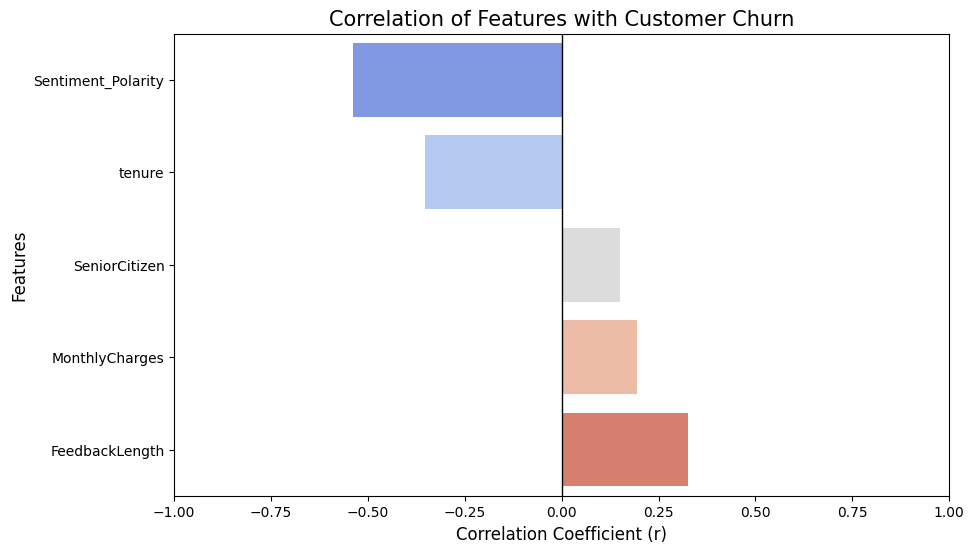

In [83]:
plt.figure(figsize=(10, 6))
sns.barplot(x=correlations.values, y=correlations.index, palette='coolwarm')

plt.title('Correlation of Features with Customer Churn', fontsize=15)
plt.xlabel('Correlation Coefficient (r)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.xlim(-1, 1)
plt.axvline(0, color='black', lw=1) # Add a vertical line at 0
plt.show()

From the figure its observed:
1. As feedback length & Monthly charges increase, the customer is likely to churn since it becomes expensive and the feedback is usually emotionally charged and lengthy.
2. As sentiment polarity becomes more negative i.e. customers are angrier/unsatisfied, they are likely to churn.
3. Customers tend to stay when their stay has been longer with the company and they are less likely to churn.